# Phase 2 — Descente de gradient à la main

## Objectif

On entraîne un neurone sigmoid à la main sur un petit problème de classification binaire.

Dans cette phase, on va :
- faire le forward pass ;
- calculer la loss avec la BCE ;
- calculer les gradients ;
- mettre à jour les paramètres ;
- observer la diminution de la loss au cours de l'entraînement.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = np.array([
    [0.2, 0.1],
    [0.8, 0.9],
    [0.3, 0.7],
    [0.9, 0.2]
], dtype=float)

y = np.array([0, 1, 1, 0], dtype=float)

print("X shape :", X.shape)
print("y shape :", y.shape)
print("X =\n", X)
print("y =", y)

X shape : (4, 2)
y shape : (4,)
X =
 [[0.2 0.1]
 [0.8 0.9]
 [0.3 0.7]
 [0.9 0.2]]
y = [0. 1. 1. 0.]


## 1. Principe

On part du même neurone que dans la phase 1, mais cette fois les poids ne sont plus fixés à la main.

À chaque epoch :

1. on calcule les prédictions ;
2. on mesure l'erreur ;
3. on calcule les gradients ;
4. on corrige les paramètres.

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## 2. Formules

Forward pass :

$$
z = Xw + b
$$

$$
\hat{y} = \sigma(z)
$$

Binary cross-entropy :

$$
L = -\frac{1}{n} \sum \left( y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right)
$$

Pour un neurone sigmoid avec BCE, les gradients se simplifient en :

$$
\frac{\partial L}{\partial w} = \frac{1}{n} X^T (\hat{y} - y)
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum (\hat{y} - y)
$$

Mise à jour :

$$
w = w - \eta \frac{\partial L}{\partial w}
$$

$$
b = b - \eta \frac{\partial L}{\partial b}
$$

In [6]:
np.random.seed(42)

w = np.random.randn(2) * 0.01
b = 0.0

learning_rate = 0.1
n_epochs = 50
losses = []

print("w initial =", w)
print("b initial =", b)
print("learning_rate =", learning_rate)
print("n_epochs =", n_epochs)

w initial = [ 0.00496714 -0.00138264]
b initial = 0.0
learning_rate = 0.1
n_epochs = 50


In [81]:
for epoch in range(n_epochs):
    # Forward pass
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # Loss
    loss = compute_loss(y, y_pred)
    losses.append(loss)

    # Gradients
    error = y_pred - y
    dw = (1 / len(X)) * np.dot(X.T, error)
    db = (1 / len(X)) * np.sum(error)

    # Mise à jour
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w.round(3)} | b: {b:.3f}")

Epoch   0 | Loss: 0.0349 | w: [-2.217 10.512] | b: -3.635
Epoch  10 | Loss: 0.0348 | w: [-2.219 10.521] | b: -3.638
Epoch  20 | Loss: 0.0347 | w: [-2.221 10.53 ] | b: -3.641
Epoch  30 | Loss: 0.0346 | w: [-2.223 10.539] | b: -3.645
Epoch  40 | Loss: 0.0345 | w: [-2.225 10.548] | b: -3.648


In [82]:
print("\nParamètres finaux")
print("w =", w)
print("b =", b)

z_final = np.dot(X, w) + b
y_pred_final = sigmoid(z_final)
y_class_final = (y_pred_final > 0.5).astype(int)

print("\nPrédictions finales :", y_pred_final.round(3))
print("Classes prédites    :", y_class_final)
print("Vraies classes      :", y.astype(int))
print("Loss finale         :", round(losses[-1], 4))


Paramètres finaux
w = [-2.22629754 10.55606206]
b = -3.6505229426755426

Prédictions finales : [0.046 0.983 0.956 0.028]
Classes prédites    : [0 1 1 0]
Vraies classes      : [0 1 1 0]
Loss finale         : 0.0344


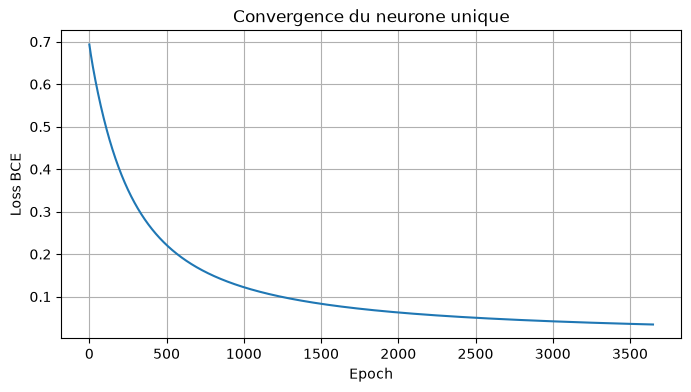

In [83]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss BCE")
plt.title("Convergence du neurone unique")
plt.grid(True)
plt.show()

## 3. Vérification attendue

On doit observer :

- une loss initiale proche de 0.69 ;
- une loss qui diminue régulièrement au fil des epochs ;
- des poids qui changent progressivement ;
- une loss finale nettement plus faible que la loss initiale.

Dans mon exécution :
- la courbe descend correctement ;
- le neurone apprend bien ;
- la convergence est visible sur le graphique.

Tests utiles :
- si `learning_rate = 0`, rien ne bouge ;
- si `learning_rate` est trop grand, la loss peut osciller ou diverger.